In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import seaborn.objects as so
from seaborn import axes_style
import matplotlib.pyplot as plt

In [2]:
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.clustering.k_means import TimeSeriesKMeans
from sktime.dists_kernels.dtw import DtwDist
from sktime.alignment.dtw_numba import AlignerDtwNumba
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score


In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
theme_dict = {**axes_style('whitegrid'), 'context': 'notebook', 'palette': 'muted'}
so.Plot.config.theme.update(theme_dict)

In [4]:
data_dir = Path('../../results')

In [5]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
# Make rating category ordinal
train['rating_category'] = pd.Categorical(train['rating_category'],
               categories=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
               ordered=True)
train.sort_values('numVotes', ascending=False).head(5)

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0816692,Interstellar,2014,169,2374947,"['US', 'GB', 'CA']",True,8.7,"['Adventure', 'Drama', 'Sci-Fi']",High,3.487517e+08,...,593663.0,720577.0,896340.0,1070807.0,991763.0,910905.0,786939.0,660732.0,710859.0,763250.0
tt0993846,The Wolf of Wall Street,2013,180,1703709,['US'],True,8.2,"['Biography', 'Comedy', 'Crime']",High,2.150253e+08,...,516835.0,636727.0,921125.0,1212685.0,959817.0,733352.0,485552.0,215064.0,230368.0,244186.0
tt7286456,Joker,2019,122,1625673,"['US', 'CA', 'AU']",True,8.3,"['Crime', 'Drama', 'Thriller']",High,6.322560e+08,...,1908740.0,1371816.0,943600.0,426673.0,513630.0,609986.0,533751.0,443301.0,383414.0,328871.0
tt4154796,Avengers: Endgame,2019,181,1374452,['US'],NaN,8.4,"['Action', 'Adventure', 'Sci-Fi']",High,1.589580e+09,...,1829579.0,1583859.0,1057981.0,598373.0,700030.0,790276.0,686876.0,601476.0,570854.0,547331.0
tt4154756,Avengers: Infinity War,2018,149,1302471,"['US', 'NO']",True,8.4,"['Action', 'Adventure', 'Sci-Fi']",High,1.276892e+09,...,2644515.0,2403780.0,1719860.0,922933.0,1054992.0,1182541.0,1051254.0,895177.0,820151.0,766901.0


In [6]:
train.shape

(850, 110)

## Preparation of the dataset

Convert in a format that sktime can use. For future reference, for panel timeseries expects on of:
- pandas dataframe with row multi-index (instances, time) cols = variables;
- 3D numpy array
- list of pandas dataframes with list index=instances, rows = time points and cols = variables

[see documentation](https://www.sktime.net/en/latest/examples/AA_datatypes_and_datasets.html#Section-1.2:-Time-series-panels---the-%22Panel%22-scitype)

In [7]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])
train_X

,,value
id,time,
tt10855768,0,3433703.0
tt3766354,0,13375850.0
tt6791096,0,6199651.0
tt1821549,0,35536.0
tt7144666,0,10241355.0
...,...,...
tt7668870,99,26209.0
tt8884430,99,36465.0
tt9883996,99,2417.0


Sanity check on the output of the transformers.

In [8]:
scaler = TabularToSeriesAdaptor(StandardScaler())

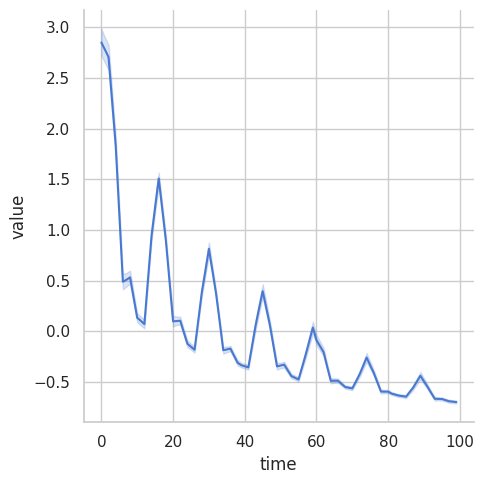

In [9]:
sns.relplot(scaler.fit_transform(train_X), x='time', y='value', kind='line')

## Visualization of some distances

In [10]:
idxs =  ['tt0816692', 'tt4154796', 'tt1663202', 'tt6751668']

movies = [train.loc[idx, 'title'] for idx in idxs]

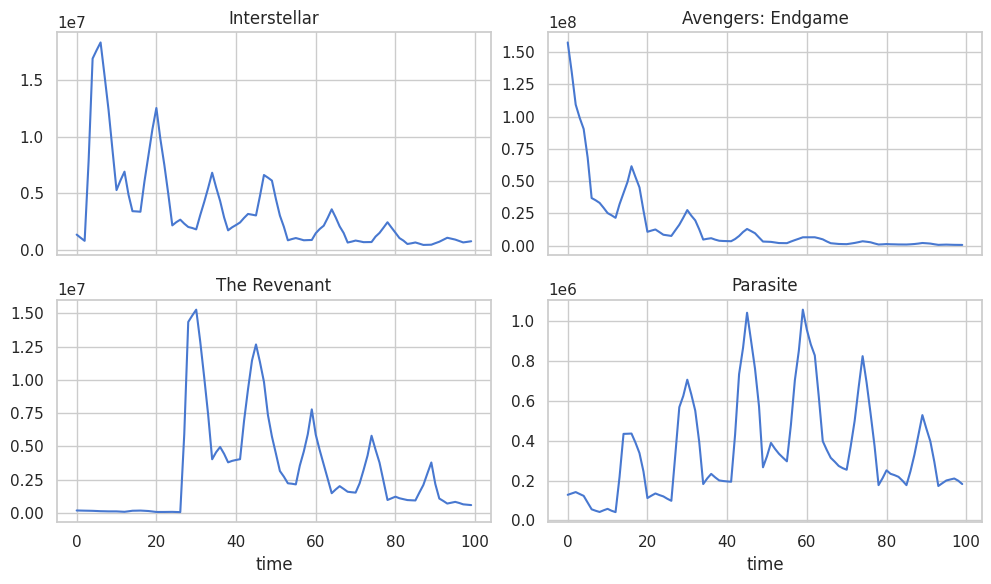

In [11]:
fig, axs = plt.subplots(2, 2, sharey=False, sharex=True, figsize=(10, 6))
sns.lineplot(train_X.loc[idxs[0]], legend=False, ax=axs[0, 0])
axs[0, 0].set_title(movies[0])
sns.lineplot(train_X.loc[idxs[1]], legend=False, ax=axs[0, 1])
axs[0, 1].set_title(movies[1])
sns.lineplot(train_X.loc[idxs[2]], legend=False, ax=axs[1, 0])
axs[1, 0].set_title(movies[2])
sns.lineplot(train_X.loc[idxs[3]], legend=False, ax=axs[1, 1])
axs[1, 1].set_title(movies[3])
plt.tight_layout()

In [12]:
train_X_norm = scaler.fit_transform(train_X)

In [13]:
data = train_X_norm.loc[idxs]

Text(0.5, 1.0, 'Distance matrix (STW with band=0.1)')

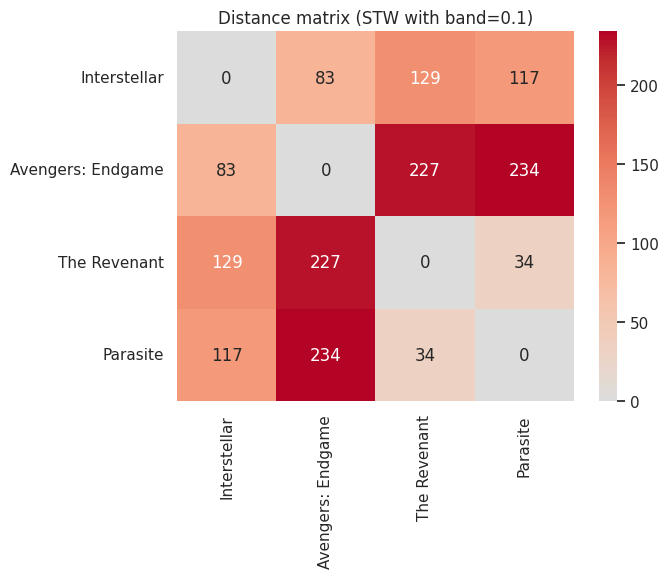

In [14]:
band = .1

dtw = DtwDist(window=band)
sns.heatmap(dtw.transform(data), cmap='coolwarm', center=0, annot=True, fmt='.0f', xticklabels=movies, yticklabels=movies, )
plt.title(f'Distance matrix (STW with band={band})')

In [15]:
aligner = AlignerDtwNumba(window=band)

In [16]:
def plot_alignments(idx1, idx2):
    ts1, ts2 = data.loc[idxs[idx1]], data.loc[idxs[idx2]]
    aligner.fit([ts1, ts2])
    alignments = aligner.get_alignment()
    plt.plot(ts1, c="C0", label=movies[idx1])
    plt.plot(ts2, c="C1", label=movies[idx2])
    for _, row in alignments.iterrows():
        ind0 = row['ind0']
        ind1 = row['ind1']
        plt.plot([ind0, ind1], [ts1.iloc[ind0], ts2.iloc[ind1]], color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

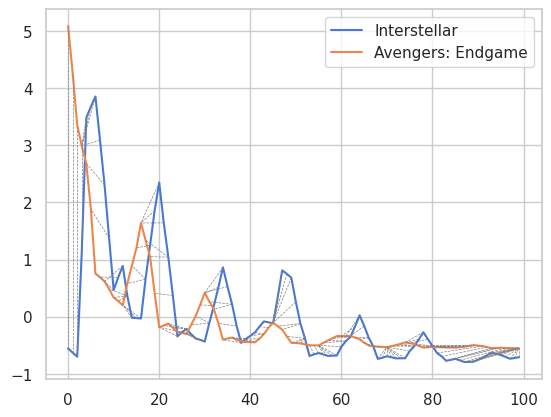

In [17]:
plot_alignments(0, 1)

## Distance Matrix

In [18]:
import numpy as np

We compute the distance matrix in order to estimate dbscan parameters and to use in hierarchical clustering.

In [19]:
%%time
pipeline  = scaler * dtw
dist_matrix = pipeline.transform(train_X)

CPU times: user 19.2 s, sys: 73.3 ms, total: 19.3 s
Wall time: 19.4 s


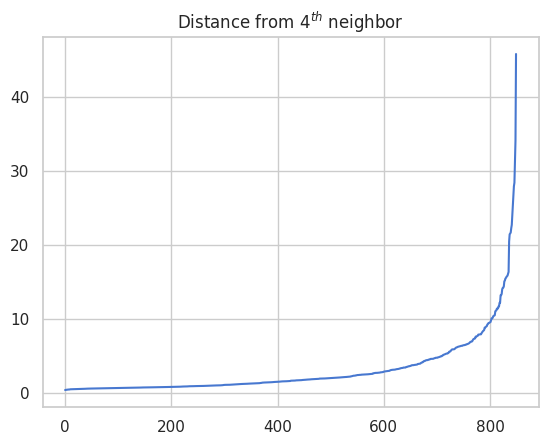

In [20]:
k = 4
distances = []

for d in dist_matrix:
    sorted_indexes = np.argsort(d)
    distances.append(d[sorted_indexes[k]])

plt.plot(range(len(distances)), sorted(distances))
plt.title(r'Distance from $%s^{th}$ neighbor'%k)
plt.show()

## Kmeans

In [21]:
kmeans = TimeSeriesKMeans(n_clusters=2, metric='dtw',
                          distance_params=dict(window=band))

In [22]:
pipeline = scaler * kmeans

In [23]:
%%time
pipeline.fit(train_X)

CPU times: user 9.11 s, sys: 108 ms, total: 9.22 s
Wall time: 9.26 s


ClustererPipeline(clusterer=TimeSeriesKMeans(distance_params={'window': 0.1},
                                             n_clusters=2),
                  transformers=[TabularToSeriesAdaptor(transformer=StandardScaler())])

In [24]:
labels = pipeline.clusterer_.labels_

In [25]:
import numpy as np
np.unique(labels, return_counts=True)

(array([0, 1]), array([159, 691]))

In [26]:
train['kmeans'] = labels
train_X_norm['kmeans'] = pd.Categorical(train_X_norm.index.get_level_values(0).map(train['kmeans']))

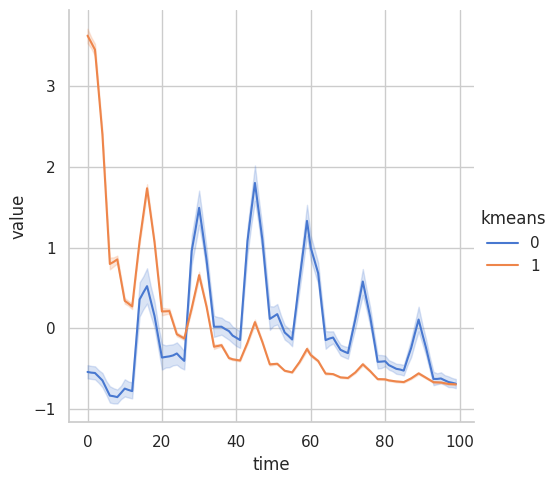

In [27]:
sns.relplot(train_X_norm, x='time', y='value', kind='line', hue='kmeans')


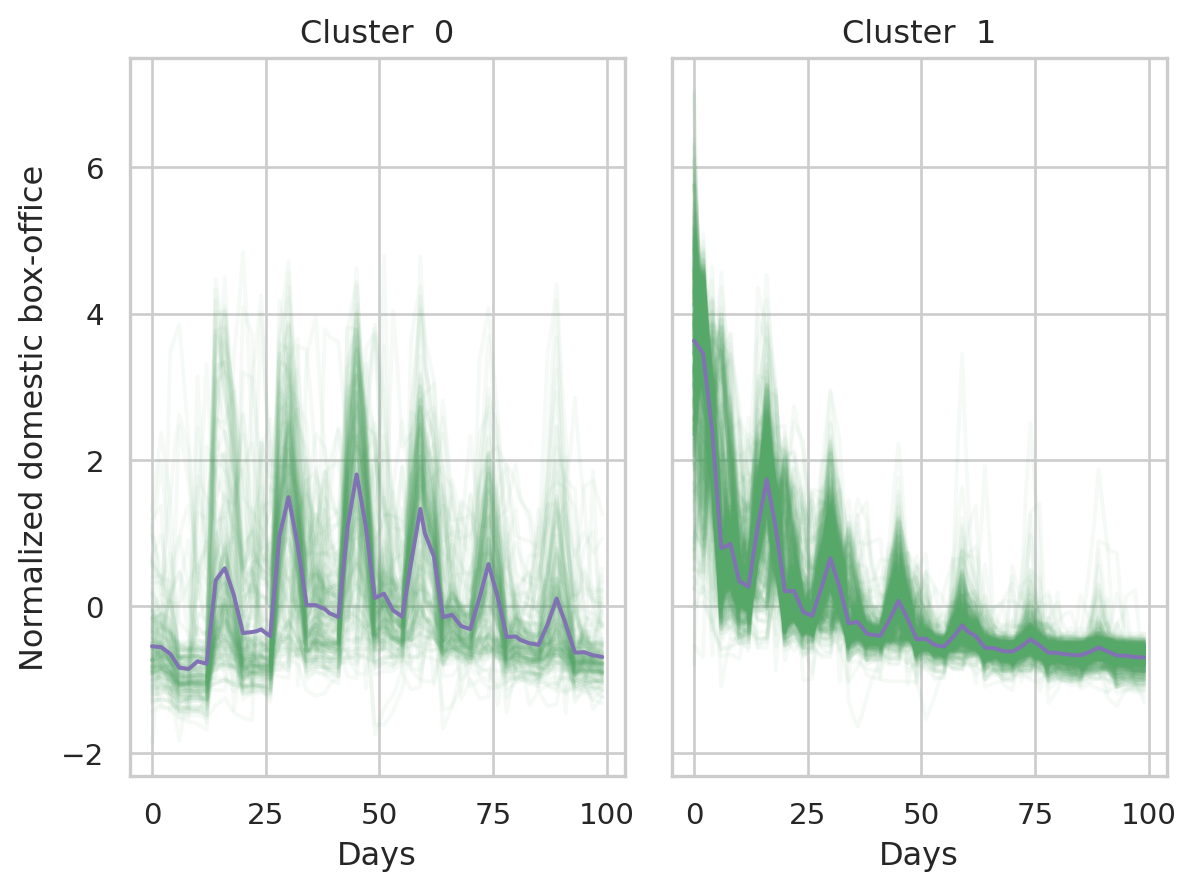

In [28]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='kmeans')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
)

This is more or less the same pattern we found in during data understanding.

In [29]:
print("Silhouette score:", silhouette_score(dist_matrix, labels, metric='precomputed'))

Silhouette score: 0.8499607983102749


## DBSCAN

We run dbscan and hierarchical clustering on a precomputed matrix using sklearn clusterers even though it is slower (?), because we can't be bothered with sktime release schedule.

In [30]:
dbscan = DBSCAN(eps=10, min_samples=4, metric='precomputed', n_jobs=-1)

In [31]:
%%time
dbscan.fit(dist_matrix)

CPU times: user 10.1 ms, sys: 6 ms, total: 16.1 ms
Wall time: 15.1 ms


,eps,10
,min_samples,4
,metric,'precomputed'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,-1


In [32]:
np.unique(dbscan.labels_, return_counts=True)

(array([-1,  0,  1]), array([ 25, 821,   4]))

In [33]:
train['dbscan'] = dbscan.labels_
train_X_norm['dbscan'] = pd.Categorical(train_X_norm.index.get_level_values(0).map(train['dbscan']))

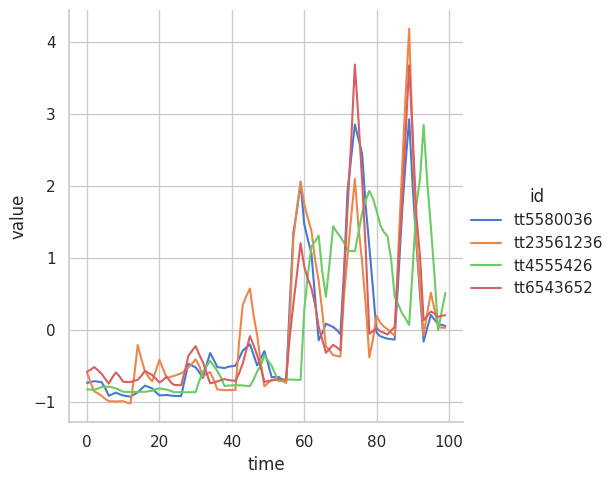

In [34]:
sns.relplot(train_X_norm[train_X_norm['dbscan'] == 1], x='time', y='value', kind='line', hue='id')

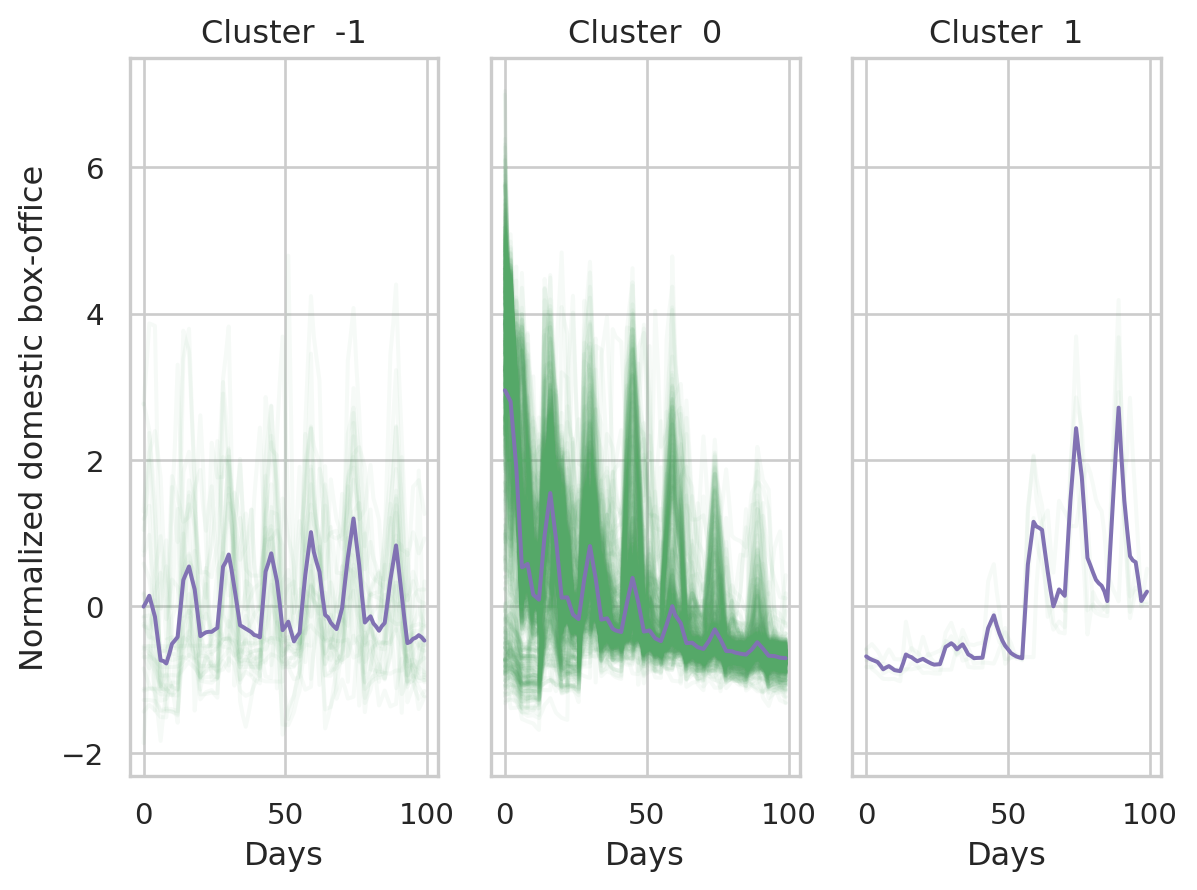

In [35]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='dbscan')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
)

## Hierarchical clustering

We attempt to create a clustering with single, average and complete link: the best dendrogram is obtained with complete linkage.

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [37]:
def get_linkage_matrix(model):
    # Create linkage matrix

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [38]:
hier_clust = AgglomerativeClustering(metric='precomputed', n_clusters=None, distance_threshold=0, linkage='complete')

In [39]:
%%time
hier_clust.fit(dist_matrix)

CPU times: user 20.3 ms, sys: 3.03 ms, total: 23.3 ms
Wall time: 51.4 ms


,n_clusters,None
,metric,'precomputed'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,0
,compute_distances,False


In [40]:
threshold = 200

([], [])

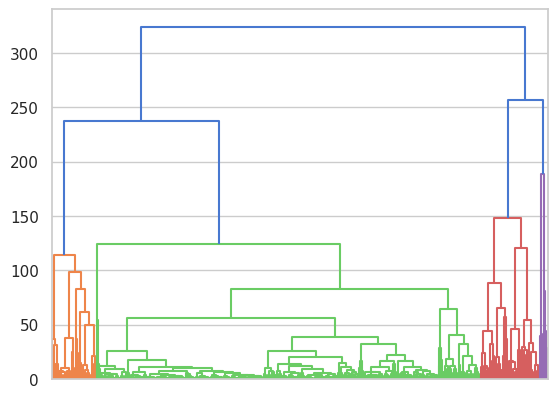

In [41]:
plot_dendrogram(hier_clust, color_threshold=threshold)
plt.xticks([], [])

In [42]:
linkage_matrix = get_linkage_matrix(hier_clust)
labels = fcluster(linkage_matrix, criterion='distance', t=threshold)

In [43]:
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32), array([ 76, 658, 101,  15]))

In [44]:
print("Silhouette score:", silhouette_score(dist_matrix, labels, metric='precomputed'))

Silhouette score: 0.7692047613528188


In [45]:
train['hier'] = pd.Categorical(labels)
train_X_norm['hier'] = train_X_norm.index.get_level_values(0).map(train['hier'])

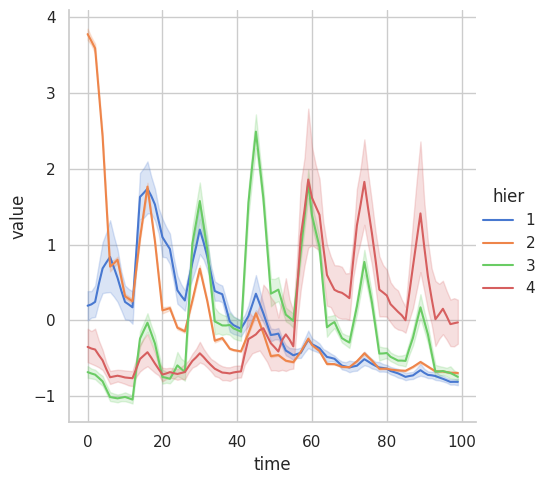

In [46]:
sns.relplot(train_X_norm, x='time', y='value', kind='line', hue='hier')

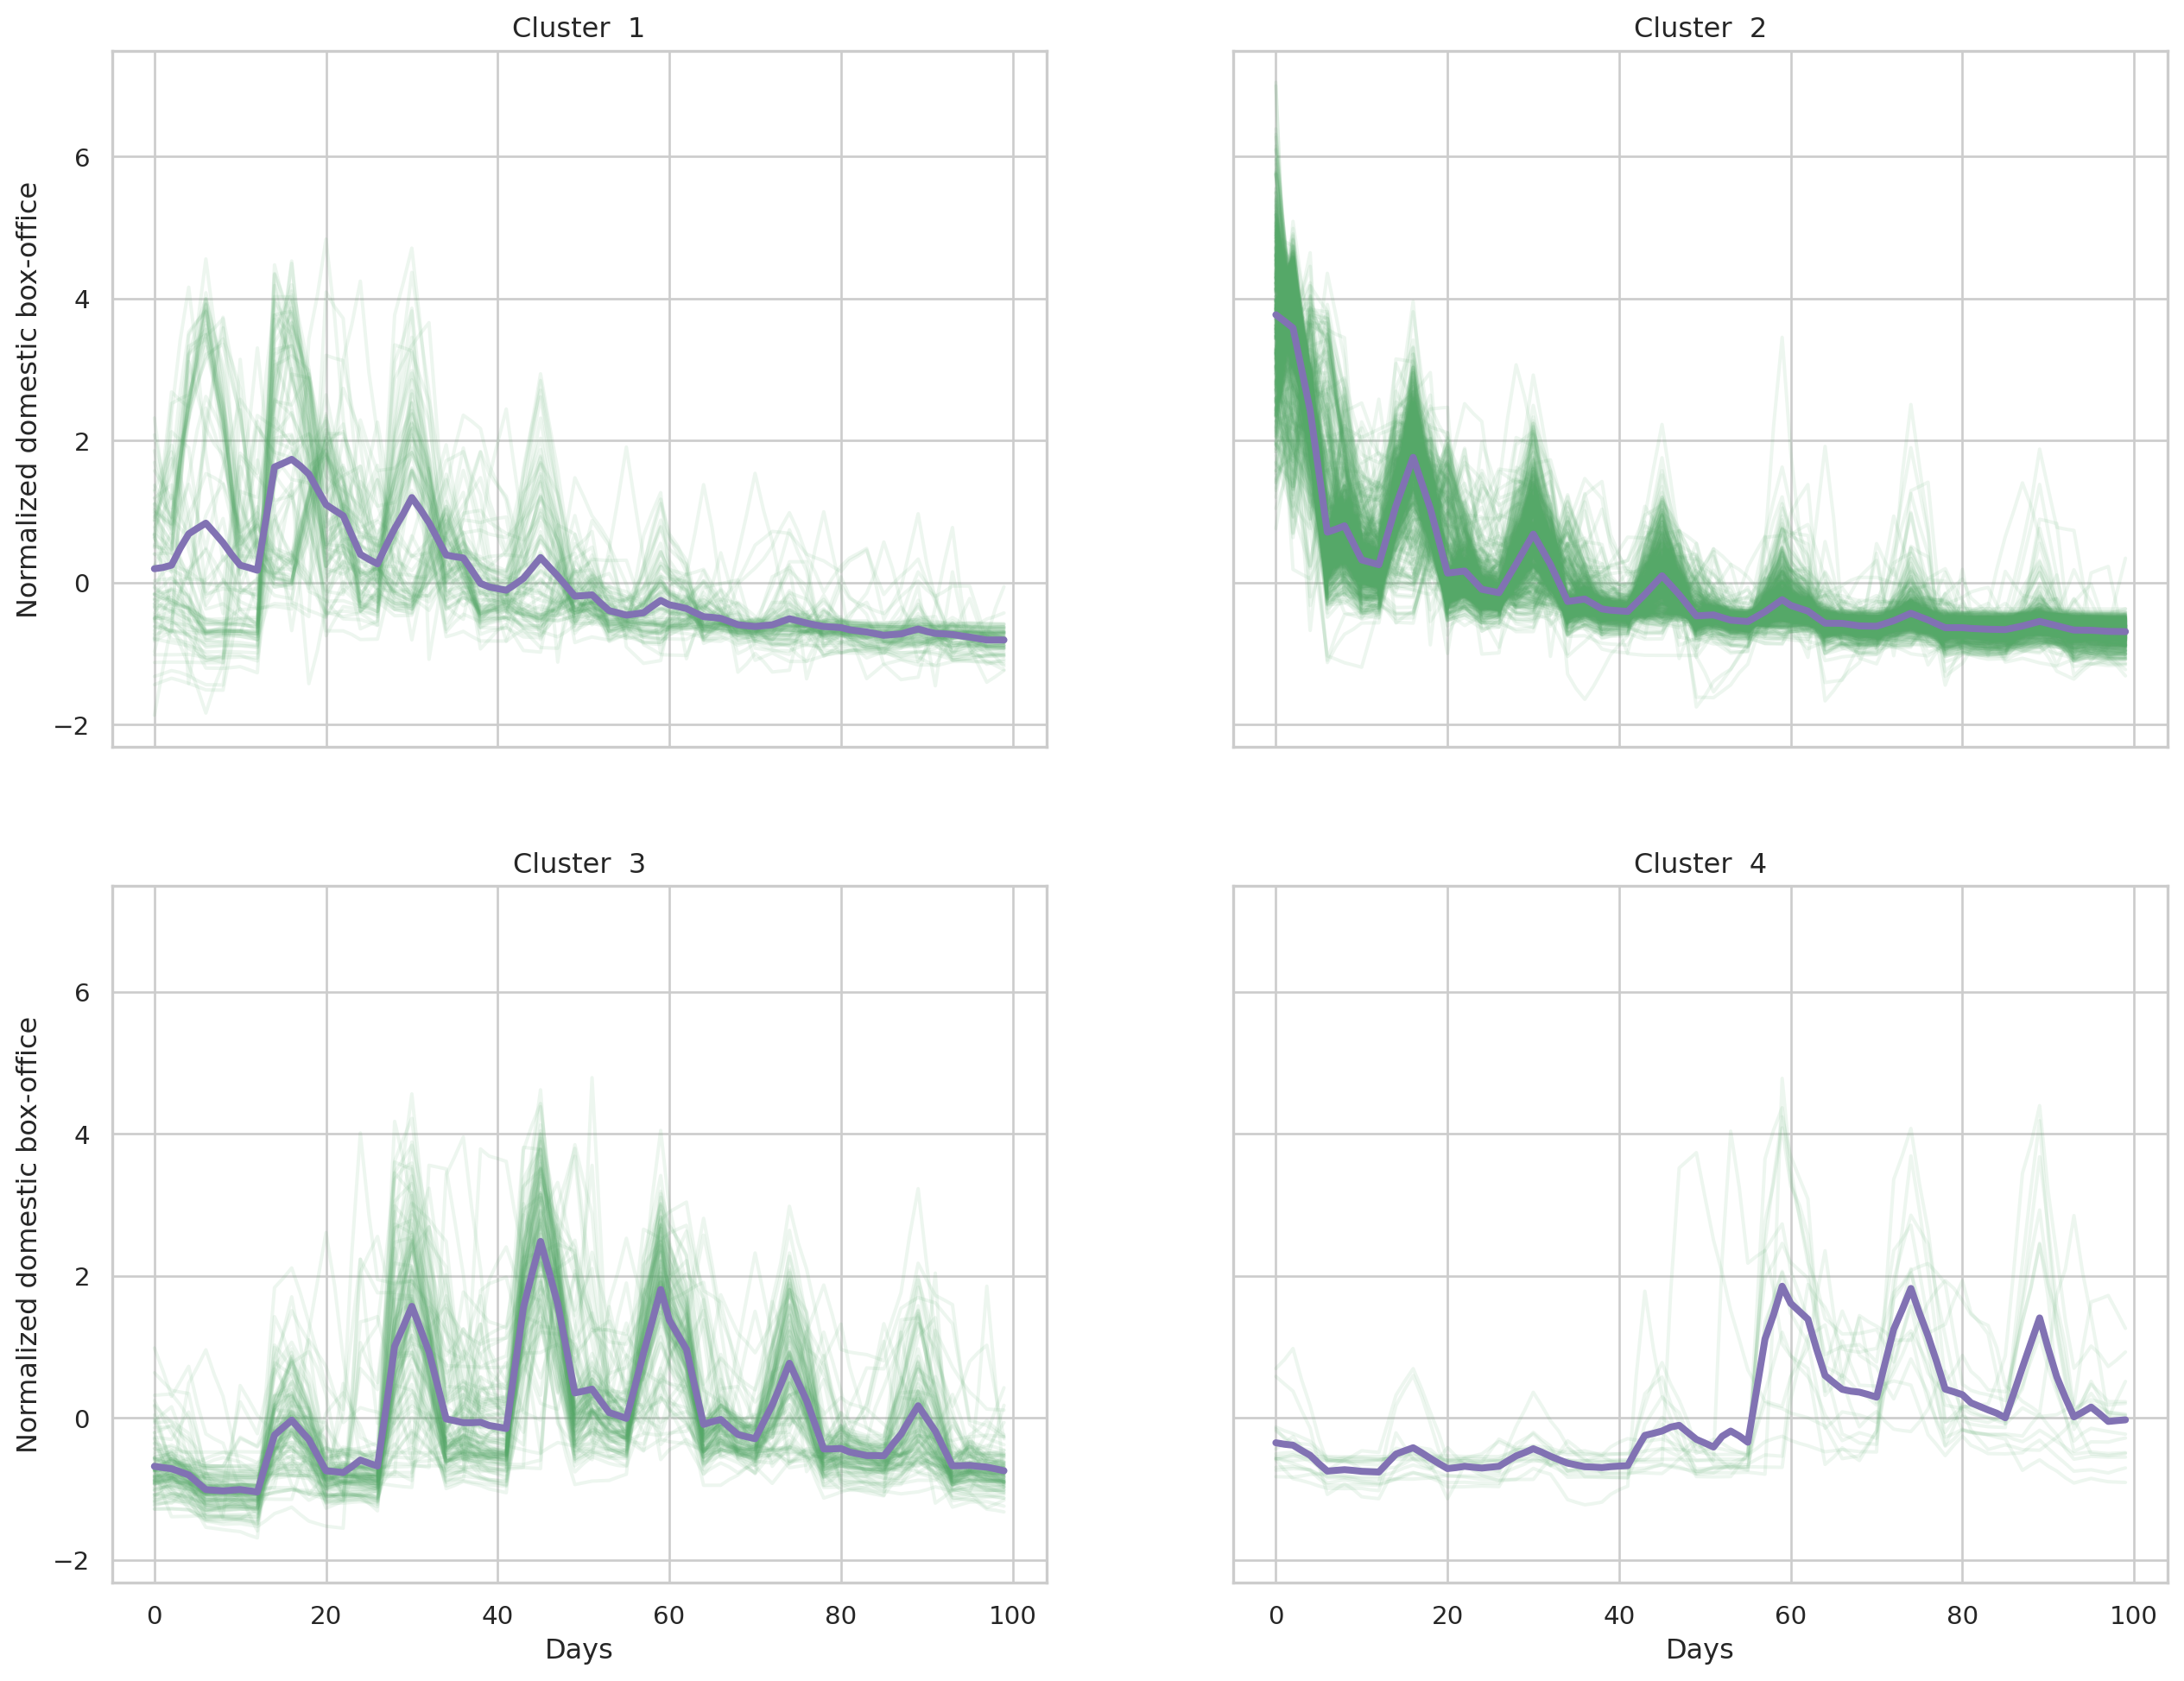

In [47]:
f = plt.Figure(figsize=(16, 12))
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='hier', wrap=2)
    .add(so.Lines(alpha=.1, color='C2'), group='id')
    .add(so.Line(color='C4', linewidth=3), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
    .on(f)
)

In [48]:
def get_medoids(dist_matrix, labels):
    medoids = []
    dist_matrix_df = pd.DataFrame(dist_matrix, index=train.index.get_level_values(0), columns=train.index.get_level_values(0))
    grouped = dist_matrix_df.groupby(labels)
    for _, group in grouped:
        medoids.append(group[group.index].sum(axis=0).idxmin())
    return medoids

In [49]:
medoids = get_medoids(dist_matrix, labels)
movies = list(train.loc[medoids, 'title'])
movies

['The Wandering Earth',
 'Mad Max: Fury Road',
 '12 Years a Slave',
 'The Danish Girl']

In [50]:
train.loc[medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,93,94,95,96,97,98,99,kmeans,dbscan,hier
id,,,,,,,,,,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38319,['CN'],True,5.9,"['Action', 'Adventure', 'Sci-Fi']",Medium,11715373.0,...,1659.0,2056.0,2413.0,2081.0,1818.0,1399.0,949.0,1,0,1
tt1392190,Mad Max: Fury Road,2015,120,1173873,"['AU', 'US']",True,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0,...,242233.0,243773.0,245481.0,209339.0,178396.0,197961.0,217511.0,1,0,2
tt2024544,12 Years a Slave,2013,134,768847,"['GB', 'US']",True,8.1,"['Biography', 'Drama', 'History']",High,69357605.0,...,158756.0,179126.0,201277.0,188885.0,176761.0,178445.0,180084.0,0,0,3
tt0810819,The Danish Girl,2015,119,204065,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,7.1,"['Biography', 'Drama']",High,16716240.0,...,91727.0,99937.0,112969.0,112714.0,112374.0,117609.0,121652.0,0,-1,4


Visualization of cluster medoids.

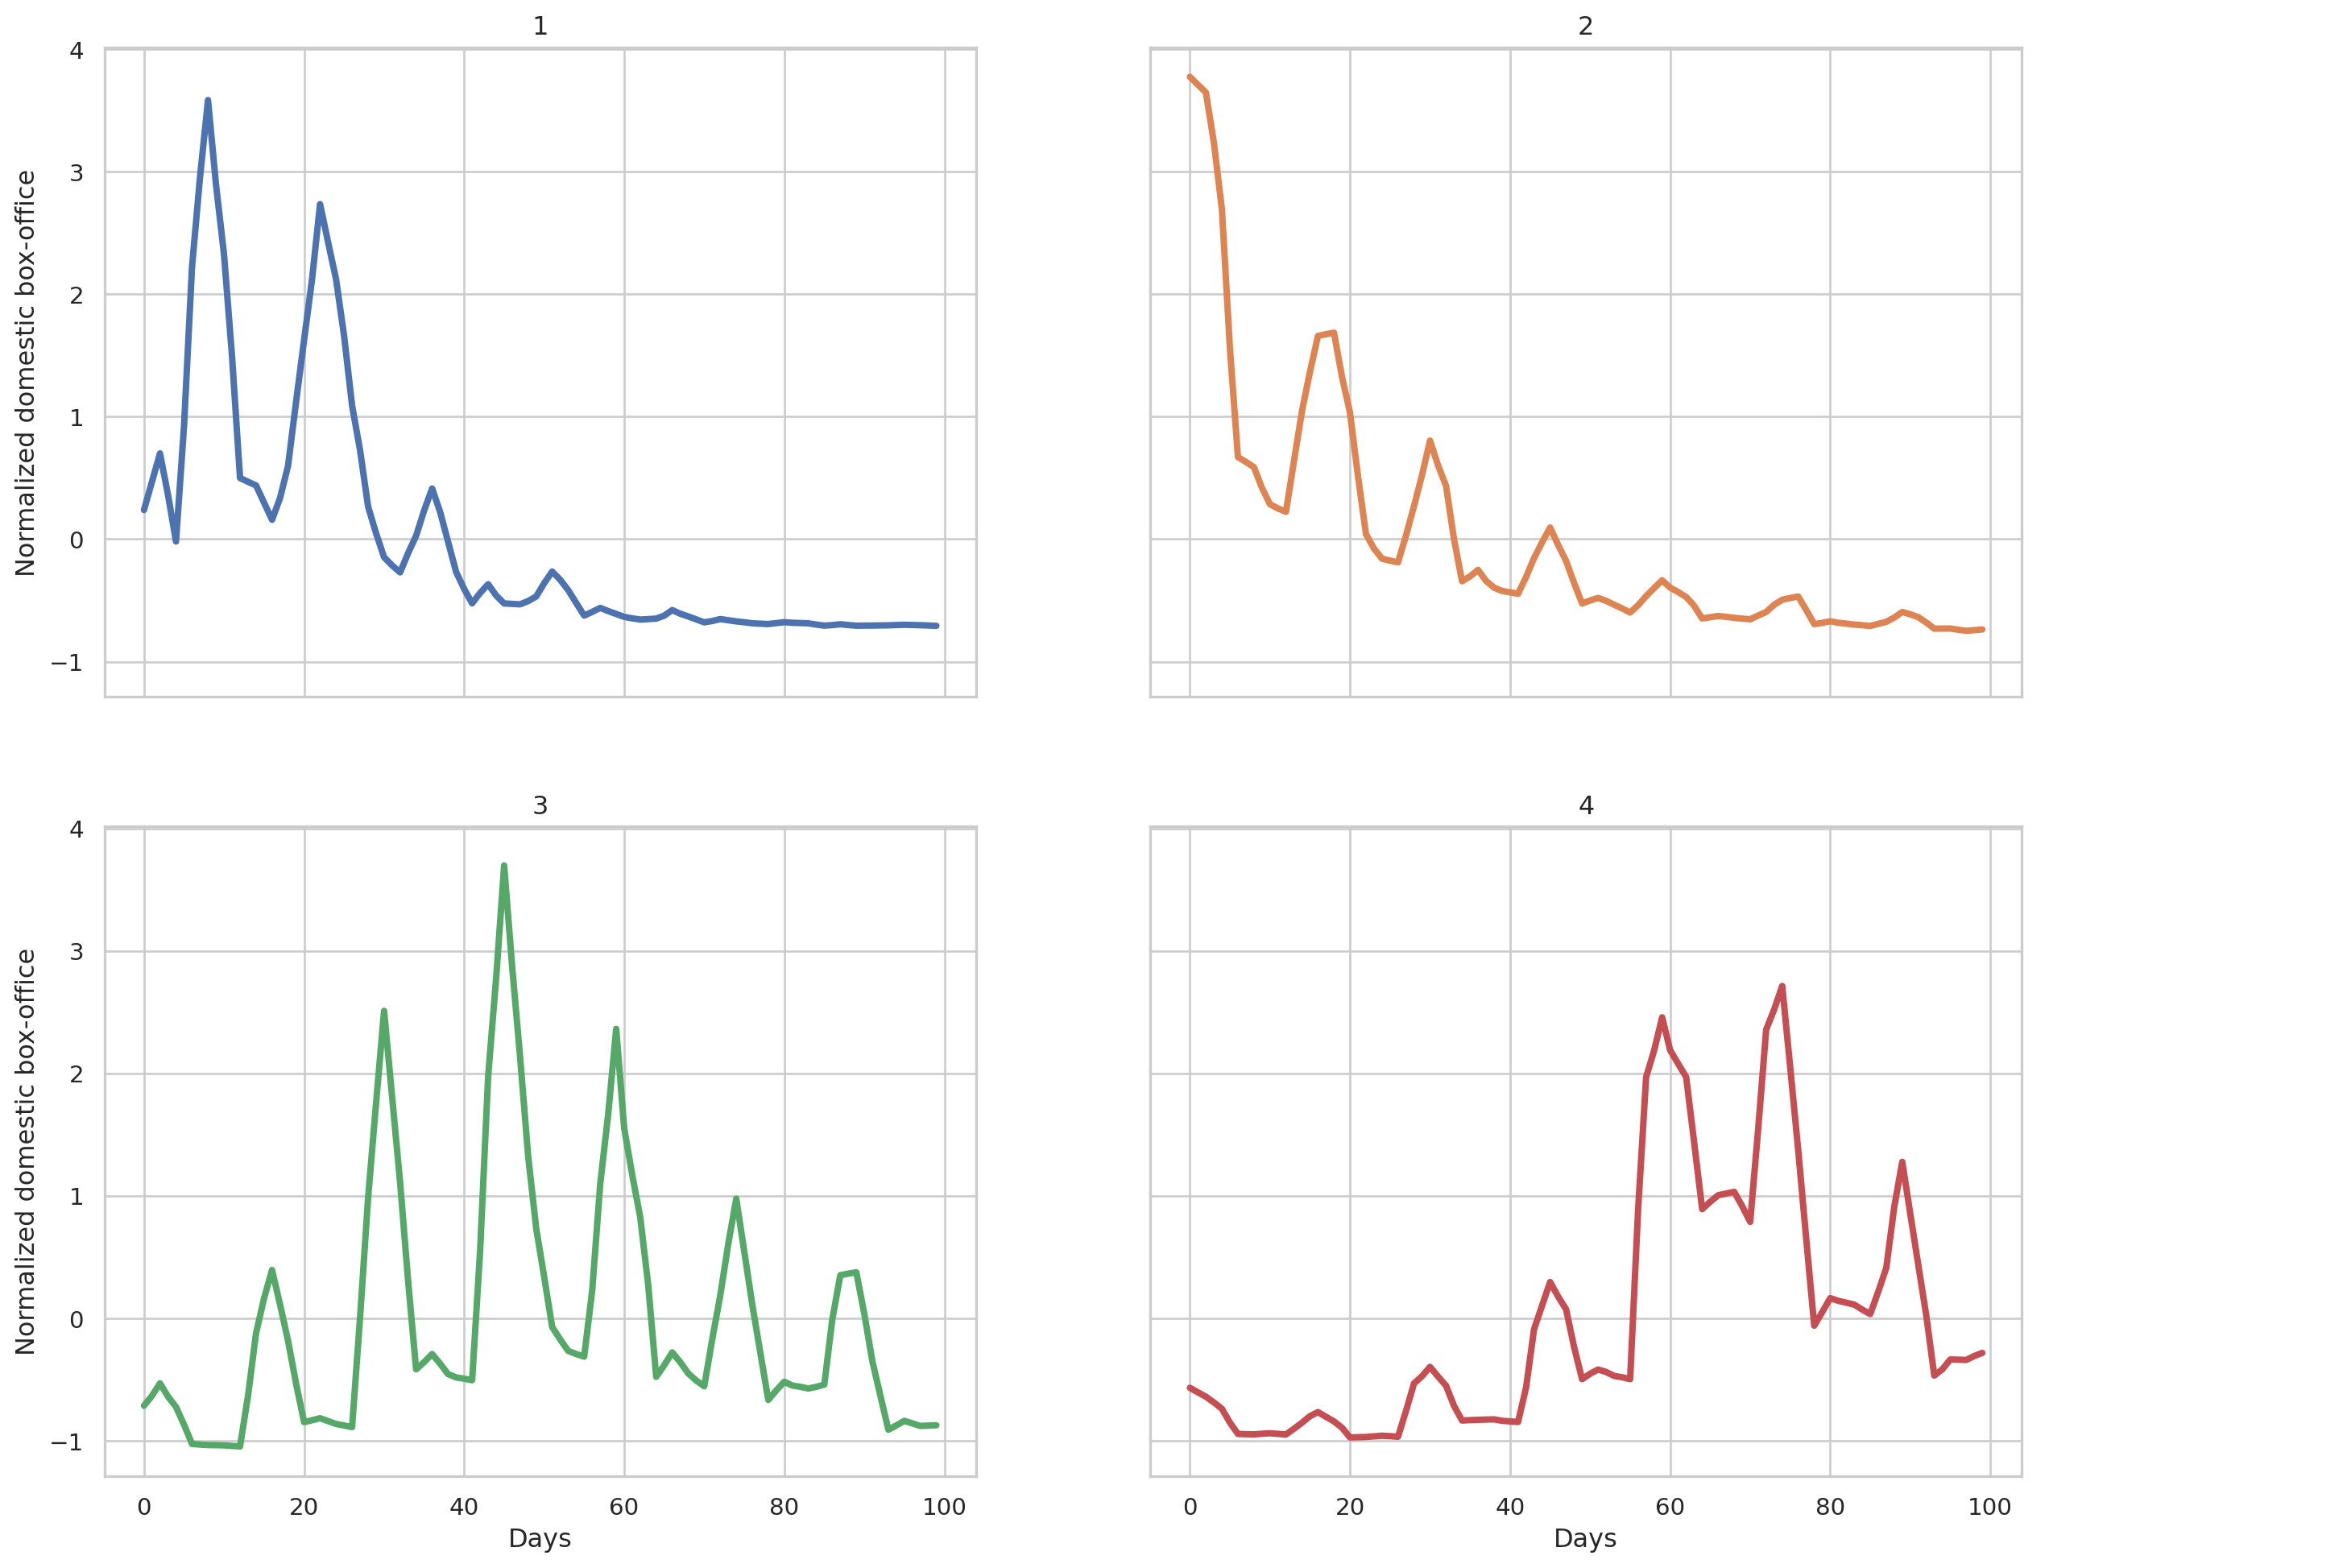

In [51]:
f = plt.Figure(figsize=(16, 12))
(
    so.Plot(train_X_norm.loc[medoids], x='time', y='value', color='hier')
    .facet(col='hier', wrap=2)
    .add(so.Lines(linewidth=3))
    .label(x='Days', y='Normalized domestic box-office')
    .on(f)
)

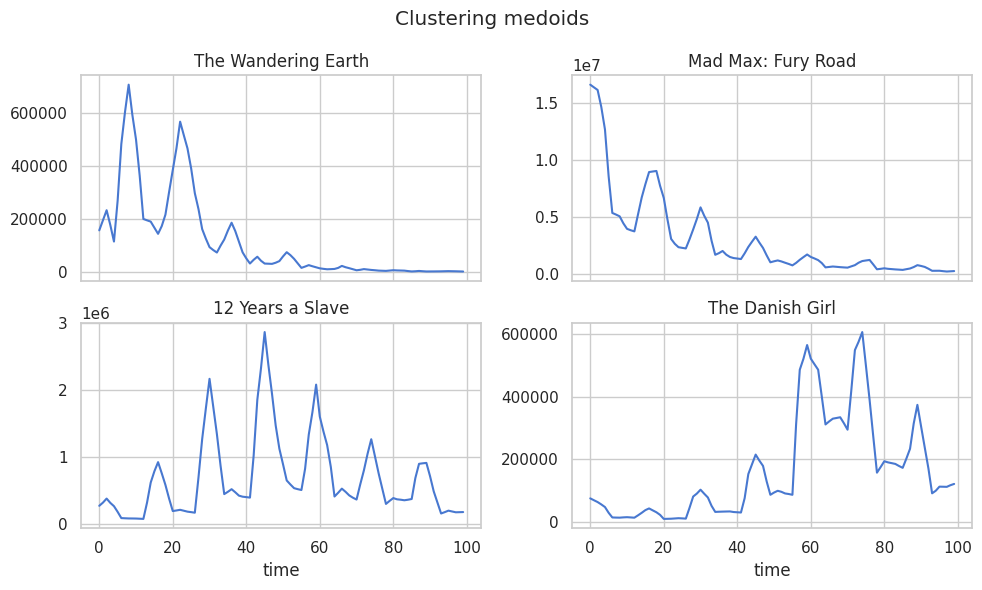

In [52]:
fig, axs = plt.subplots(2, 2, sharey=False, sharex=True, figsize=(10, 6))
sns.lineplot(train_X.loc[medoids[0]], legend=False, ax=axs[0, 0])
axs[0, 0].set_title(movies[0])
sns.lineplot(train_X.loc[medoids[1]], legend=False, ax=axs[0, 1])
axs[0, 1].set_title(movies[1])
sns.lineplot(train_X.loc[medoids[2]], legend=False, ax=axs[1, 0])
axs[1, 0].set_title(movies[2])
sns.lineplot(train_X.loc[medoids[3]], legend=False, ax=axs[1, 1])
axs[1, 1].set_title(movies[3])
fig.suptitle("Clustering medoids")
plt.tight_layout()

In [53]:
clustering = 'hier'

Text(0, 0.5, 'Density')

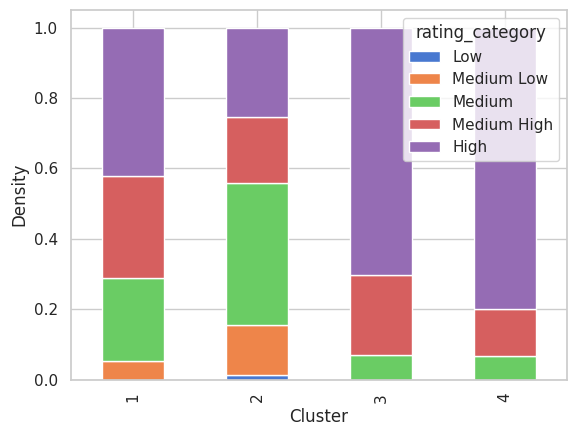

In [54]:
pd.crosstab(train[clustering], train['rating_category'], normalize='index').plot.bar(stacked=True)
plt.xlabel('Cluster')
plt.ylabel('Density')

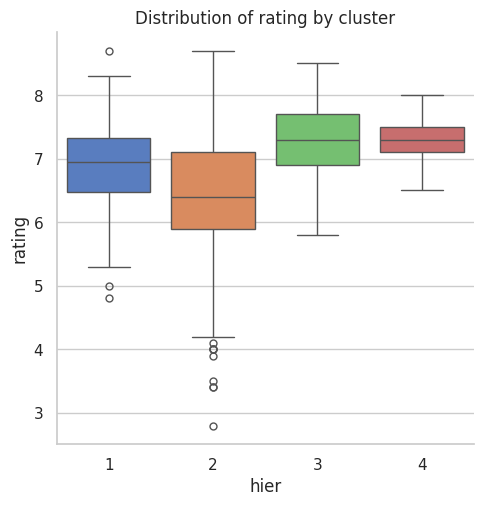

In [55]:
sns.catplot(train, x=clustering, y='rating', kind='box', hue=clustering, legend=False)
plt.title("Distribution of rating by cluster")
plt.show()

Records from cluster 3 are rated more favorably.

<Axes: xlabel='hier'>

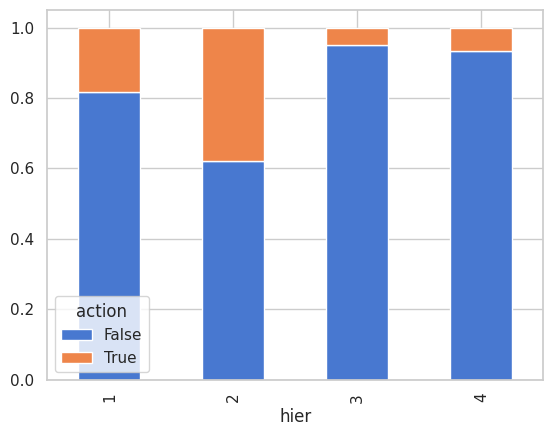

In [56]:
train['action'] = train['genre'].map(lambda x: 'Action' in x)
pd.crosstab(train[clustering], train['action'], normalize='index').plot.bar(stacked='True')

<Axes: xlabel='hier'>

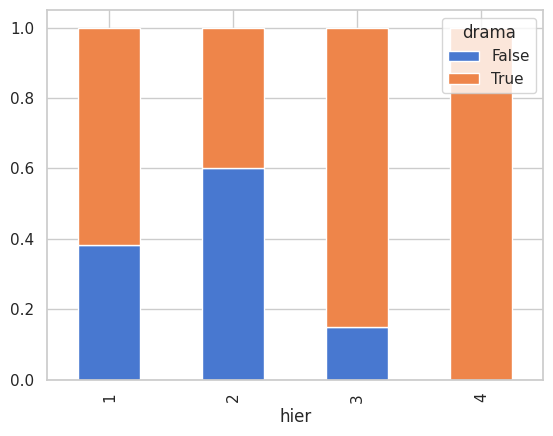

In [57]:
train['drama'] = train['genre'].map(lambda x: 'Drama' in x)
pd.crosstab(train[clustering], train['drama'], normalize='index').plot.bar(stacked='True')

Action movies are underrepresented in cluster 3, while dramatic movies are overrepresented (dramatic movies make up about half of the dataset but than 80% of cluster 3).

<Axes: xlabel='hier'>

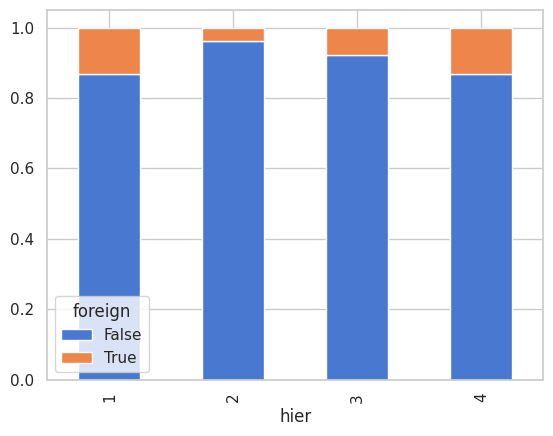

In [58]:
train['foreign'] = train['countryOfOrigin'].apply(lambda x: 'US' not in x)
pd.crosstab(train[clustering], train['foreign'], normalize='index').plot.bar(stacked=True)

<Axes: xlabel='hier'>

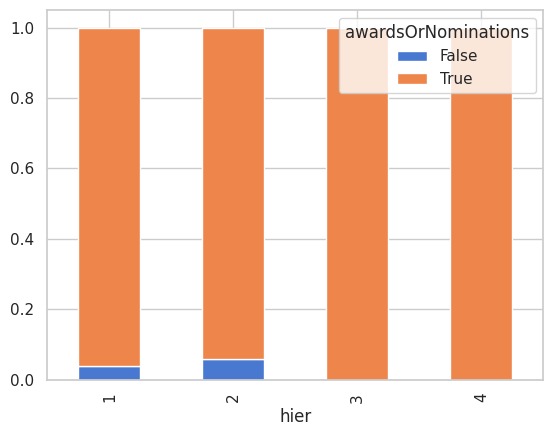

In [59]:
pd.crosstab(train[clustering], train['awardsOrNominations'], normalize='index').plot.bar(stacked='True')